# 지연 오차 분석

`dataset.parquet` 기준. 목적은 **모델이 어디서 얼마나 틀리는지 밝히고, 남은 오차가
줄일 수 있는 것인지 판별하는 것**이다.

> ⚠️ **현재 항공편 4일치(527편)뿐이다.** 아래 수치는 전부 잠정이며 결론으로 인용하면 안 된다.
> 이 노트북의 용도는 분석 틀을 미리 세워 두는 것이고, 데이터가 쌓이면 그대로 재실행한다.

**결론 먼저**

1. 지연은 **음수로 쏠려 있다**(중앙값 −9분). 계획에 여유가 들어 있어 정시 도착이 곧 조기 도착이다.
   그래서 "중앙값을 항상 찍는" 베이스라인이 이미 MAE 13분대를 낸다 — 이기기 어려운 기준선이다.
2. 사전예측 모델은 아직 **베이스라인보다 나쁘다**(R² 음수). 기상·노선·시간대만으로는
   개별 편의 지연을 설명하지 못하고, 현재 표본에서는 과적합만 남는다.
3. 이륙 후 모델은 MAE 4분대로 뚜렷이 낫다. 다만 이는 **출발지연을 알기 때문**이고,
   남은 오차는 비행시간 변동(실측 표준편차 6.1분)에 갇혀 있어 더 줄이기 어렵다.
4. **큰 지연(15~60분)에서 베이스라인·사전예측은 MAE 40분대로 무너지지만 이륙 후 모델은 5분대를
   유지한다.** 정작 예측이 필요한 구간을 상수 예측으로는 전혀 못 잡는다는 뜻이다.
5. 학습곡선에서 사전예측 MAE 가 학습 50편 26.8분 → 400편 15.9분으로 **뚜렷이 내려오는 중**이다.
   아직 베이스라인(13분대) 위지만 하강이 멈추지 않았으므로, 신호가 없어서가 아니라
   **표본이 부족해서** 지고 있을 가능성이 높다. 축적을 기다리는 것이 지금의 유일한 개선책이다.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error

sys.path.insert(0, str(Path.cwd().parent))
from config import DATA_PROCESSED
from src.train import CATEGORICAL, FEATURES_PRE, PARAMS, TARGET, split_by_time

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="AppleGothic", rc={"axes.unicode_minus": False})

df = pd.read_parquet(DATA_PROCESSED / "dataset.parquet")
print(f"{len(df):,}편  ({df.sched_time.min():%Y-%m-%d} ~ {df.sched_time.max():%Y-%m-%d})")
print(f"출발지연 보유 {df.dep_delay.notna().sum():,}편 ({df.dep_delay.notna().mean() * 100:.0f}%)")

527편  (2026-09-07 ~ 2026-09-10)
출발지연 보유 154편 (29%)


## 1. 타겟 분포 — 왜 베이스라인이 강한가

지연 예측에서 가장 먼저 확인할 것은 타겟이 어디에 몰려 있는지다.

count   527.00
mean     -5.20
std      22.10
min     -65.00
25%     -17.00
50%      -9.00
75%       1.50
max     165.00

정시(±0분) 이내 도착: 73%
15분 이상 지연:        10%


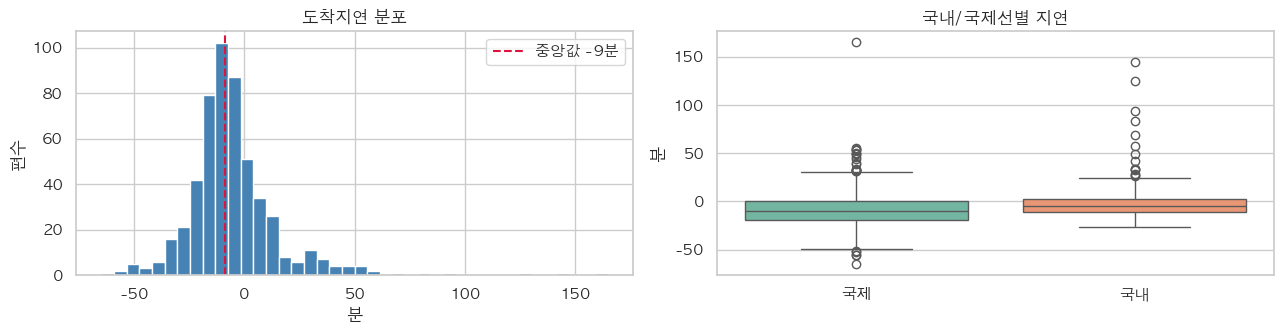

In [2]:
print(df[TARGET].describe().round(1).to_string())
print(f"\n정시(±0분) 이내 도착: {(df[TARGET] <= 0).mean() * 100:.0f}%")
print(f"15분 이상 지연:        {(df[TARGET] >= 15).mean() * 100:.0f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].hist(df[TARGET], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(df[TARGET].median(), color="crimson", ls="--", label=f"중앙값 {df[TARGET].median():+.0f}분")
axes[0].set(title="도착지연 분포", xlabel="분", ylabel="편수")
axes[0].legend()

sns.boxplot(data=df, x="line", y=TARGET, ax=axes[1], hue="line", legend=False, palette="Set2")
axes[1].set(title="국내/국제선별 지연", xlabel="", ylabel="분")
plt.tight_layout()

분포가 **0이 아니라 음수(−9분)를 중심으로** 서 있다. 항공사가 계획 비행시간에 여유(버퍼)를
넣어 두기 때문에, 아무 일 없이 운항하면 계획보다 일찍 도착하는 것이 정상이다.

이 구조 때문에 **"항상 중앙값을 찍는" 베이스라인이 강력하다.** 지연이 0 근처에 좁게 몰려
있으므로 상수 예측만으로 MAE 13분대가 나온다. 모델이 이걸 이기려면 개별 편의 편차를
실제로 설명해야 하고, 그게 이 프로젝트의 난이도다.

## 2. 세 모델의 잔차 — 어디서 벌어지나

`train.py` 와 동일한 조건(시간 기준 분할, 같은 피처·파라미터)으로 학습하되,
잔차를 보기 위해 예측값을 직접 받는다.

In [3]:
from xgboost import XGBRegressor


def fit_predict(features, train, test):
    """train.py 의 run_xgb 와 같은 방식으로 학습하고 예측값을 돌려준다."""
    x_train, x_test = train[features].copy(), test[features].copy()
    for col in set(CATEGORICAL) & set(features):
        cats = pd.CategoricalDtype(x_train[col].dropna().unique())
        x_train[col] = x_train[col].astype(cats)
        x_test[col] = x_test[col].astype(cats)
    model = XGBRegressor(**PARAMS).fit(x_train, train[TARGET])
    return model, model.predict(x_test)


# 세 모델을 같은 표본에서 비교해야 하므로 출발지연 보유 부분집합을 쓴다.
sub = df[df.dep_delay.notna()]
tr, te = split_by_time(sub, 0.2)
print(f"부분집합 {len(sub)}편 → 학습 {len(tr)} / 테스트 {len(te)}")

pred = pd.DataFrame({"실제": te[TARGET].values}, index=te.index)
pred["베이스라인"] = tr[TARGET].median()
model_pre, pred["사전예측"] = fit_predict(FEATURES_PRE, tr, te)
model_post, pred["이륙후"] = fit_predict([*FEATURES_PRE, "dep_delay"], tr, te)

MODELS = ["베이스라인", "사전예측", "이륙후"]
print()
for m in MODELS:
    print(f"{m:6s} MAE {mean_absolute_error(pred['실제'], pred[m]):5.2f}분")

부분집합 154편 → 학습 123 / 테스트 31



베이스라인  MAE  9.87분
사전예측   MAE 12.09분
이륙후    MAE  3.92분


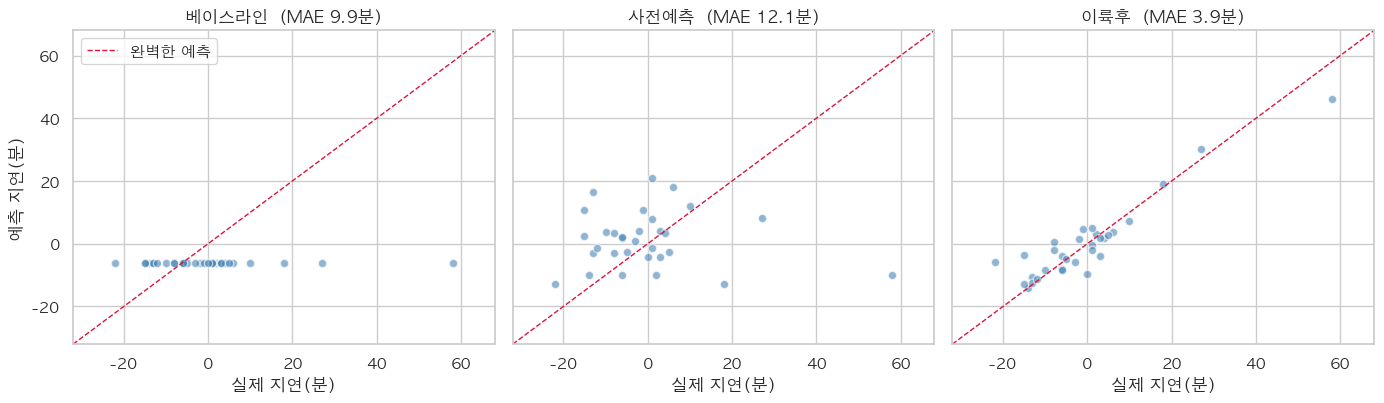

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True, sharey=True)
lim = (pred["실제"].min() - 10, pred["실제"].max() + 10)

for ax, m in zip(axes, MODELS):
    ax.scatter(pred["실제"], pred[m], alpha=0.6, color="steelblue", edgecolor="white")
    ax.plot(lim, lim, ls="--", color="crimson", lw=1, label="완벽한 예측")
    ax.set(title=f"{m}  (MAE {mean_absolute_error(pred['실제'], pred[m]):.1f}분)",
           xlabel="실제 지연(분)", xlim=lim, ylim=lim)
axes[0].set_ylabel("예측 지연(분)")
axes[0].legend(loc="upper left")
plt.tight_layout()

       베이스라인   사전예측    이륙후
count  31.00  31.00  31.00
mean   -5.40   2.10   0.60
std    14.80  17.80   5.50
min   -64.00 -67.90 -11.90
25%    -9.00  -3.20  -2.30
50%    -4.00   5.10   0.40
75%     3.00  11.10   2.70
max    16.00  29.50  16.30


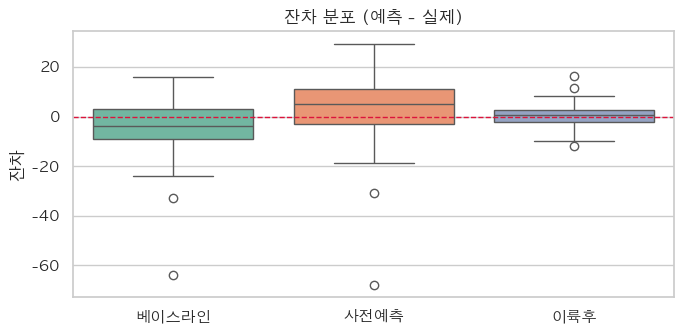

In [5]:
resid = pred[MODELS].sub(pred["실제"], axis=0)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.boxplot(data=resid.melt(var_name="모델", value_name="잔차"),
            x="모델", y="잔차", ax=ax, hue="모델", legend=False, palette="Set2")
ax.axhline(0, color="crimson", ls="--", lw=1)
ax.set(title="잔차 분포 (예측 - 실제)", xlabel="")
plt.tight_layout()
print(resid.describe().round(1).to_string())

산점도에서 갈리는 지점이 분명하다. **베이스라인과 사전예측은 수평선에 가깝다** — 실제 지연이
얼마든 비슷한 값을 뱉는다는 뜻이고, 사전예측은 거기에 헛된 진동만 얹었다. 반면
**이륙 후 모델만 대각선을 따라간다.**

즉 현재 오차의 대부분은 "출발이 늦었는지"를 모르는 데서 온다. 기상·노선·시간대는
그 정보를 대신해 주지 못한다.

## 3. 오차 분해 — 어떤 편에서 크게 틀리나

절대오차를 조건별로 쪼갠다. **표본이 작아 각 칸의 편수를 반드시 함께 본다.**

In [6]:
err = te.copy()
for m in MODELS:
    err[f"AE_{m}"] = (pred[m] - pred["실제"]).abs().values

# 지연 크기 구간별 — 큰 지연일수록 틀리는가
bins = [-100, -15, 0, 15, 60, 200]
labels = ["-15분↓(조기)", "-15~0분", "0~15분", "15~60분", "60분↑"]
err["구간"] = pd.cut(err[TARGET], bins=bins, labels=labels)

by_band = err.groupby("구간", observed=True).agg(
    편수=("구간", "size"), **{m: (f"AE_{m}", "mean") for m in MODELS}).round(1)
print("■ 지연 크기 구간별 평균절대오차(분)")
print(by_band.to_string())

■ 지연 크기 구간별 평균절대오차(분)
           편수  베이스라인  사전예측  이륙후
구간                             
-15분↓(조기)   3  11.30 17.40 9.90
-15~0분     15   3.70  8.90 3.20
0~15분      10   9.60  7.20 2.70
15~60분      3  40.30 39.20 5.40


In [7]:
print("■ 시간대별 (편수 3편 이상)")
by_hour = err.groupby("hour").agg(
    편수=("hour", "size"), **{m: (f"AE_{m}", "mean") for m in MODELS}).round(1)
print(by_hour[by_hour.편수 >= 3].to_string())

print("\n■ 출발지별 (편수 3편 이상)")
by_org = err.groupby("origin").agg(
    편수=("origin", "size"), **{m: (f"AE_{m}", "mean") for m in MODELS}).round(1)
print(by_org[by_org.편수 >= 3].sort_values("이륙후", ascending=False).to_string())

■ 시간대별 (편수 3편 이상)
      편수  베이스라인  사전예측  이륙후
hour                      
9      3   4.70  8.40 1.40
10     4   8.80 12.70 6.60
11     4  10.00  6.30 3.00
14     4  13.50 10.20 3.70
20     4  20.00 22.00 3.80
21     4   2.00  5.00 2.10

■ 출발지별 (편수 3편 이상)
        편수  베이스라인  사전예측  이륙후
origin                      
GMP     13   8.80 10.40 4.20
CJU     18  10.60 13.30 3.70


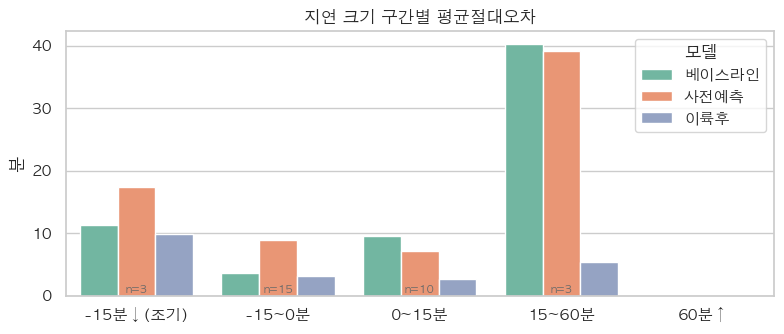

In [8]:
plot_df = by_band.reset_index().melt(id_vars=["구간", "편수"], value_vars=MODELS,
                                     var_name="모델", value_name="MAE")
ax = sns.barplot(data=plot_df, x="구간", y="MAE", hue="모델", palette="Set2")
ax.set(title="지연 크기 구간별 평균절대오차", xlabel="", ylabel="분")
for i, n in enumerate(by_band.편수):
    ax.text(i, 0.5, f"n={n}", ha="center", fontsize=8, color="dimgray")
plt.gcf().set_size_inches(8, 3.5)
plt.tight_layout()

여기서 모델이 갈린다. **15~60분 지연 구간에서 베이스라인 40.3분·사전예측 39.2분으로 둘 다
무너지는데, 이륙 후 모델만 5.4분을 유지한다.** 상수 예측은 정시 근처 편에서만 맞고 정작
예측이 필요한 큰 지연에서는 쓸모가 없다 — 낮은 MAE 가 곧 쓸모를 뜻하지 않는다는 증거다.

그래서 보고서에는 MAE 하나만이 아니라 **"15분 이상 지연을 잡아냈는가"** 를 함께 적어야 한다.
전체 MAE 로는 베이스라인이 좋아 보이지만, 실무에서 필요한 구간의 성능은 정반대다.

단 각 칸이 3~15편에 불과하다. 방향만 보고 수치는 인용하지 않는다.

## 4. 사전예측 모델은 왜 베이스라인에 지는가

두 가지 가설이 있다. (a) 기상·노선에 애초에 신호가 없다, (b) 신호는 있지만 표본이 부족하다.
피처 중요도와 학습곡선으로 갈라 본다.

이륙후 모델에서 dep_delay 가 차지하는 중요도: 48%


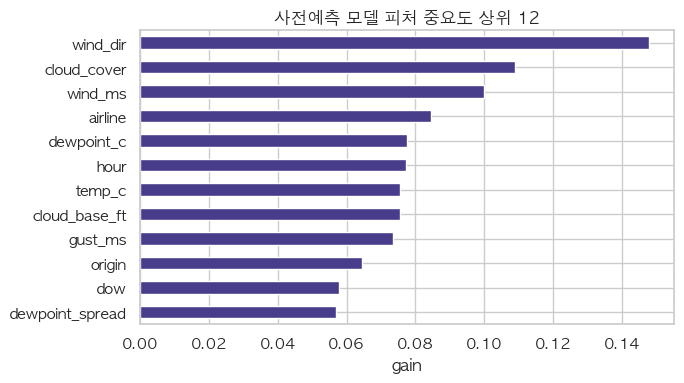

In [9]:
imp = pd.Series(model_pre.feature_importances_, index=FEATURES_PRE).sort_values()
ax = imp.tail(12).plot.barh(figsize=(7, 4), color="darkslateblue")
ax.set(title="사전예측 모델 피처 중요도 상위 12", xlabel="gain")
plt.tight_layout()

imp_post = pd.Series(model_post.feature_importances_, index=[*FEATURES_PRE, "dep_delay"])
print(f"이륙후 모델에서 dep_delay 가 차지하는 중요도: {imp_post['dep_delay'] * 100:.0f}%")

      사전예측  베이스라인
학습편수             
50   26.78  12.98
75   21.39  12.90
100  18.52  13.07
125  15.75  12.90
150  15.58  13.07
175  18.49  13.07
200  18.09  13.29
225  19.43  13.29
250  16.95  13.29
275  16.24  13.07
300  16.98  13.18
325  15.34  13.29
350  16.21  13.29
375  15.96  13.29
400  15.85  13.07


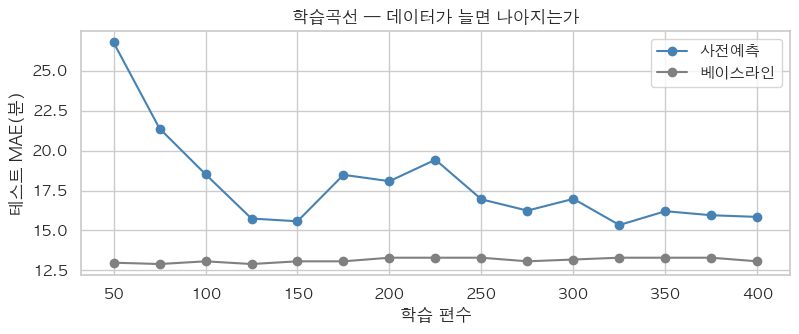

In [10]:
# 학습곡선 — 학습 데이터를 늘리면 MAE 가 내려가는가
tr_all, te_all = split_by_time(df, 0.2)
sizes = range(50, len(tr_all) + 1, 25)
curve = []
for n in sizes:
    part = tr_all.iloc[-n:]          # 테스트셋에 가장 가까운 구간부터 늘린다
    _, p = fit_predict(FEATURES_PRE, part, te_all)
    curve.append({
        "학습편수": n,
        "사전예측": mean_absolute_error(te_all[TARGET], p),
        "베이스라인": mean_absolute_error(te_all[TARGET], [part[TARGET].median()] * len(te_all)),
    })
curve = pd.DataFrame(curve).set_index("학습편수")

ax = curve.plot(figsize=(8, 3.5), marker="o", color=["steelblue", "gray"])
ax.set(title="학습곡선 — 데이터가 늘면 나아지는가", xlabel="학습 편수", ylabel="테스트 MAE(분)")
plt.tight_layout()
print(curve.round(2).to_string())

**가설 (b) 쪽이 유력하다.** 사전예측 MAE 가 학습 50편 26.8분 → 400편 15.9분으로 내려왔고,
곡선이 아직 평평해지지 않았다. 베이스라인은 같은 구간에서 13분대에 붙박여 있다 —
데이터를 늘려도 상수 예측은 나아질 여지가 없으니, 둘의 간격이 좁혀지는 것은 모델 쪽이
배우고 있다는 뜻이다. 다만 아직 교차하지 않았고, 어디서 멈출지는 현재 표본으로 알 수 없다.

`dep_delay` 는 이륙 후 모델 중요도의 48% 로 단일 피처 중 압도적 1위다. 기상 변수들은
그에 비해 미미한데, **9~12월 수집 구간에 악기상 자체가 드물다**는
`01_metar_eda.ipynb` §4 의 결론과 일치한다.

## 5. 남은 오차의 하한선

이륙 후 모델의 오차가 어디까지 줄 수 있는지는 항등식으로 확인된다.

```
도착지연 − 출발지연 = 실제 비행시간 − 계획 비행시간
```

count   154.00
mean    -24.70
std       6.10
min     -40.00
25%     -27.00
50%     -25.00
75%     -22.00
max      14.00

표준편차 6.1분 — 출발지연을 알아도 남는 불확실성의 크기
실측 이륙후 MAE 3.92분


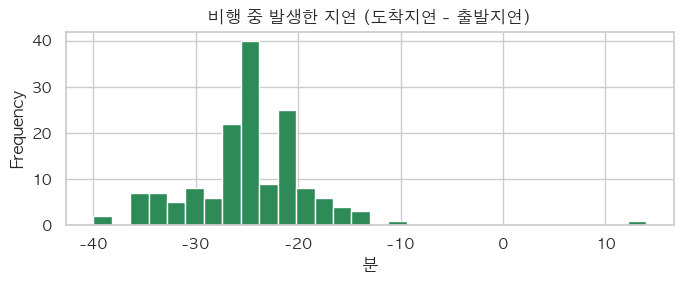

In [11]:
flown = sub[TARGET] - sub.dep_delay      # 비행 중 발생한 지연(분)
print(flown.describe().round(1).to_string())
print(f"\n표준편차 {flown.std():.1f}분 — 출발지연을 알아도 남는 불확실성의 크기")
print(f"실측 이륙후 MAE {mean_absolute_error(pred['실제'], pred['이륙후']):.2f}분")

ax = flown.plot.hist(bins=30, figsize=(7, 3), color="seagreen", edgecolor="white")
ax.set(title="비행 중 발생한 지연 (도착지연 - 출발지연)", xlabel="분")
plt.tight_layout()

**이 표준편차(6.1분)가 사실상의 하한선이다.** 출발지연을 알고 나면 남는 것은 순수한 비행시간
변동이고, 계획 비행시간이 노선별로 고정(60/65분)이므로 모델이 더 배울 여지가 거의 없다.

평균이 −24.7분인 것도 눈여겨볼 값이다. **계획에 약 25분의 여유가 들어 있다**는 뜻이라,
20분 늦게 출발해도 정시 도착으로 기록된다.

현재 실측 MAE 가 이 값보다 낮게 나오기도 하는데, 테스트 31편이라 우연히 낮게 잡힌 것으로
보는 편이 안전하다. **최종 보고서에는 표본이 충분해진 뒤의 수치를 쓴다.**

---

### 다음에 볼 것

- 데이터 축적 후 재실행 — 특히 §4 학습곡선의 수렴 여부
- 악기상이 실제로 발생한 날의 오차 (현재 표본에는 사례가 거의 없다)
- 15분 이상 지연에 대한 분류 성능(적중률·오경보율) — MAE 를 보완하는 지표